In [117]:
# !pip install gymnasium
# !pip install scipy

In [118]:
import numpy as np
import matplotlib.pyplot as plt

import math


# D200, Problem Set 3: Reinforcement Learning

This problem set introduces reinforcement learning through three
economic applications from IO and quantitative marketing. You will
progress from multi-armed bandits (ad-channel testing) to tabular
Q-learning (airline revenue management) to Deep Q-Networks
(within-session content personalisation). Each problem is
self-contained: the key RL concepts are explained before you need them.


## Multi-Armed Bandits

![Slot machines](./slot-machines.jpg)

Assume you enter a casino with three slot machines (three *bandits*).  
Each machine has an unknown probability of winning.

You are told that one machine has a much higher chance of paying out, but you do not know which one.

You can:
- **Observe others** and estimate each machine’s win frequency.
- **Play yourself** to gather data and estimate which machine is best.

This is the key trade-off in reinforcement learning:
- **Exploration**: try different machines to learn their payout probabilities.
- **Exploitation**: choose the machine that currently seems best.

If you had an unlimited budget, you could play each machine 1000 times (explore), estimate each win probability, then always play the best one (exploit).

But if your budget is limited and there are many machines, full exploration is too costly.  
Then the goal is to balance exploration and exploitation efficiently.

A central question is: **what strategy gives the best long-term reward?**

![Slot machines dist](./slot-machines-dist.png)

Let’s look at an interactive example [here](https://sglyon.github.io/bandits/).



# Problem 1: Multi-Armed Bandits for Ad Channel Selection

**The exploration-exploitation dilemma.** Suppose a firm can advertise
through several marketing channels but doesn’t know which channel
converts customers most effectively. If the firm always uses the channel
that *looks* best so far (exploitation), it might miss a better option
it hasn’t tried enough. If it keeps experimenting with all channels
equally (exploration), it wastes budget on poor performers. *Multi-armed
bandits* formalise this tradeoff: an agent repeatedly chooses one of $K$
“arms” (here, ad channels), observes a reward (conversion or not), and
must learn which arm is best while minimising total reward lost from
suboptimal choices. This is the simplest reinforcement learning setting
— there is no state, no dynamics, just a repeated decision under
uncertainty.

## Environment

The `AdChannelBandit` below simulates $K = 5$ marketing channels. Each
time you select a channel, a customer either converts (reward $= 1$) or
does not (reward $= 0$), drawn from a Bernoulli distribution with an
unknown channel-specific conversion rate. The firm’s goal is to maximise
total conversions over $T$ rounds.

![Slot machines dist](./AdChannel-dist.png)


In [119]:
class AdChannelBandit:
    """K-armed bandit for ad channel selection with Bernoulli rewards."""
    
    def __init__(self):
        self.channels = ["Email", "Social Media", "Display Ads", "Search", "Influencer"]
        self.K = len(self.channels)
        self._rates = np.array([0.08, 0.15, 0.12, 0.25, 0.05])
    
    def pull(self, arm):
        """Select a channel and observe conversion (1) or not (0)."""
        return np.random.binomial(1, self._rates[arm])
    
    def optimal_arm(self):
        """Index of the channel with the highest true conversion rate."""
        return np.argmax(self._rates)
    
    def expected_reward(self, arm):
        """True conversion rate of the given channel (used for regret calculation)."""
        return self._rates[arm]

bandit = AdChannelBandit()
print("Channels:", bandit.channels)
print(f"Number of arms (K): {bandit.K}")

Channels: ['Email', 'Social Media', 'Display Ads', 'Search', 'Influencer']
Number of arms (K): 5


**(1a)** As a baseline, run a **random policy** that selects a channel
uniformly at random each round for $T = 2000$ rounds. Plot:

1.  **Cumulative reward** (total conversions over time)
2.  **Cumulative regret** over time

**Regret** measures the cost of not always pulling the best arm. Define
per-round regret as $p^* - p_{a_t}$, where $p^* = \max_k p_k$ is the
best channel’s true conversion rate and $p_{a_t}$ is the conversion rate
of the channel chosen at round $t$. Cumulative regret sums this over all
rounds: $$R_T = \sum_{t=1}^T \left(p^* - p_{a_t}\right)$$

*Hint:* a random policy has constant expected per-round regret, so
cumulative regret grows linearly.

``` python
def run_random(bandit, T=2000):
    """Run a random policy for T rounds.
    
    Returns:
        rewards: array of length T, reward at each round (0 or 1)
        arms_played: array of length T, index of arm chosen each round
    """
    # TODO: implement
    pass

# Run the random policy and plot cumulative reward and cumulative regret
```

**Solution:**

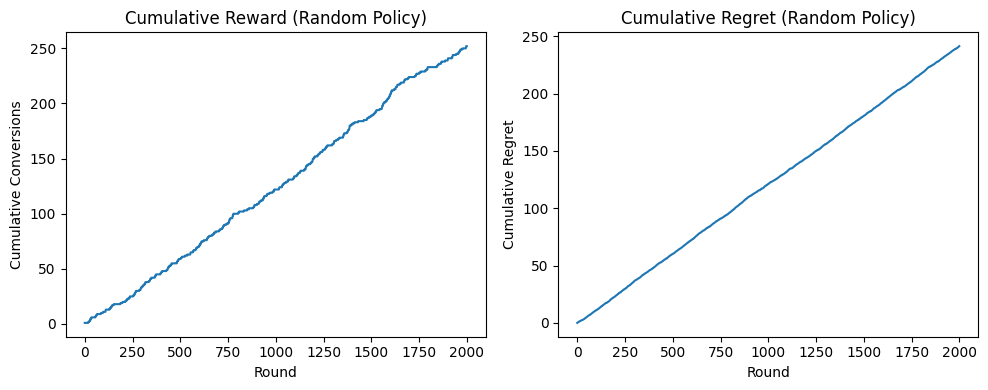

In [120]:
np.random.seed(42)   # Fix rng (for fair comparison)

def run_random(bandit, T=2000):
    
    # Allocate space
    rewards = np.zeros(T) 
    arms_played = np.zeros(T, dtype=int)

    for t in range(T):

        # Choose one of the K arms uniformly at random
        arm = np.random.randint(bandit.K) # outputs integer indices (0, 1, ..., K-1)

        # Pull the selected arm and store the realized reward for this round
        rewards[t] = bandit.pull(arm)  # Outputs 1 or 0

        # Record which arm was played at this round
        arms_played[t] = arm 

    return rewards, arms_played

# Run random policy for 2000 rounds.
rewards_rand, arms_rand = run_random(bandit, T=2000)

# Compute p*: the true expected reward of the optimal arm (best possible average win rate).
p_star = bandit.expected_reward(bandit.optimal_arm())

# Compute cumulative rewards (over time)
cum_reward = np.cumsum(rewards_rand)

# Compute cumulative regret
per_round_regret = p_star - np.array([bandit.expected_reward(a) for a in arms_rand])
cum_regret = np.cumsum(per_round_regret)


# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(cum_reward)
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Cumulative Conversions")
axes[0].set_title("Cumulative Reward (Random Policy)")

axes[1].plot(cum_regret)
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Cumulative Regret")
axes[1].set_title("Cumulative Regret (Random Policy)")

plt.tight_layout()
plt.show()

**(1b)** Implement the following three bandit algorithms and compare
them (plus the random baseline) on a single cumulative regret plot over
$T = 2000$ rounds, averaged over 50 independent runs.

1.  **$\epsilon$-greedy ($\epsilon = 0.1$):** With probability
    $\epsilon$, choose a random arm; otherwise choose the arm with the
    highest empirical mean reward. Update means incrementally:
    $\bar{r}_a \leftarrow \bar{r}_a + \frac{1}{n_a}(r_t - \bar{r}_a)$.
2.  **UCB1 ($c = 2$):** Pull each arm once, then choose
    $\arg\max_a \left[\bar{r}_a + c\sqrt{\frac{\ln t}{n_a}}\right]$
    where $n_a$ is the number of times arm $a$ has been pulled.
3.  **Thompson Sampling:** Maintain a $\text{Beta}(\alpha_a, \beta_a)$
    posterior for each arm (initialised at $\text{Beta}(1,1)$, the
    uniform prior). Each round, sample
    $\theta_a \sim \text{Beta}(\alpha_a, \beta_a)$ for every arm and
    pull $\arg\max_a \theta_a$. On observing reward $r_t \in \{0,1\}$,
    update: $\alpha_a \leftarrow \alpha_a + r_t$,
    $\beta_a \leftarrow \beta_a + (1 - r_t)$.

Each function should return `(rewards, arms_played)` arrays of length
$T$, just like `run_random`.

``` python
def epsilon_greedy(bandit, T=2000, epsilon=0.1):
    """Epsilon-greedy algorithm."""
    # TODO: implement
    pass

def ucb1(bandit, T=2000, c=2.0):
    """UCB1 algorithm."""
    # TODO: implement
    pass

def thompson_sampling(bandit, T=2000):
    """Thompson Sampling with Beta(1,1) priors."""
    # TODO: implement
    pass

# Run each algorithm for 50 independent runs and plot average cumulative regret
```


**Remarks and Solutions:**

1.  **$\epsilon$-greedy ($\epsilon = 0.1$):** The incremental mean update

$$
\bar r_a \leftarrow \bar r_a + \frac{1}{n_a}(r_t - \bar r_a)
$$

actually computes the correct empirical average:



Assume after $n_a - 1$ pulls, we know:

$$
\bar r_a^{(n_a-1)} = \frac{1}{n_a-1}\sum_{i=1}^{n_a-1} r_i
$$

Now we observe new reward $r_t$. The new mean is:

$$
\bar r_a^{(n_a)} =
\frac{1}{n_a}
\left(
\sum_{i=1}^{n_a-1} r_i + r_t
\right)
$$

Substitute the previous mean $\sum_{i=1}^{n_a-1} r_i =(n_a - 1)\bar r_a^{(n_a-1)}$:

$$
\bar r_a^{(n_a)}
=
\frac{1}{n_a}
\left(
(n_a - 1)\bar r_a^{(n_a-1)} + r_t
\right)
$$

$$
=
\frac{n_a - 1}{n_a}\bar r_a^{(n_a-1)}
+
\frac{1}{n_a} r_t

=
\bar r_a
+
\frac{1}{n_a}(r_t - \bar r_a)
$$


In [121]:
def epsilon_greedy(bandit, T=2000, epsilon=0.1):

    K = bandit.K # predetermined 

    # Allocate space
    counts = np.zeros(K)
    values = np.zeros(K)
    rewards = np.zeros(T)
    arms_played = np.zeros(T, dtype=int)
    
    # epsilon greedy
    for t in range(T):
        if np.random.random() < epsilon:
            arm = np.random.randint(K)  # interger index (explore)
        else:
            arm = np.argmax(values)  # integer index (exploit)
        
        reward = bandit.pull(arm)  # 1 or 0

        counts[arm] += 1  # n_a
        values[arm] += (reward - values[arm]) / counts[arm] # Update reward
        rewards[t] = reward  # Store reward
        arms_played[t] = arm  # Store index

        # Repeate T times
    
    return rewards, arms_played

2.  **2. UCB1 ($c = 2$):**

After pulling each arm once, choose

$$
\arg\max_a \left[\bar{r}_a + c\sqrt{\frac{\ln t}{n_a}}\right]
$$

where $n_a$ is the number of times arm $a$ has been pulled.

The idea follows from [Hoeffding’s inequality](https://en.wikipedia.org/wiki/Hoeffding%27s_inequality) for bounded rewards in $[0,1]$:

$$
\mathbb{P}\left(|\bar r_a - \mu_a| \ge \epsilon \right)
\le
2 e^{-2 n_a \epsilon^2}.
$$

Solving for $\epsilon$ such that the failure probability decreases with $t$, we obtain a confidence radius of order

$$
\epsilon \sim \sqrt{\frac{\ln t}{n_a}}.
$$

Thus, with high probability,

$$
\mu_a
\le
\bar r_a + \sqrt{\frac{\ln t}{n_a}}.
$$

The term

$$
c\sqrt{\frac{\ln t}{n_a}}
$$

acts as an **upper confidence bound** on the true mean.

- If $n_a$ is small → the bonus is large → exploration.
- If $n_a$ is large → the bonus shrinks → exploitation.

Therefore, UCB1 selects the arm with the highest plausible mean.

In [122]:
def ucb1(bandit, T=2000, c=2.0):

    K = bandit.K  # predetermined 

    # Allocate space
    counts = np.zeros(K)
    values = np.zeros(K)
    rewards = np.zeros(T)
    arms_played = np.zeros(T, dtype=int)
    
    # Pull each arm once before running the main algorithm
    for arm in range(K):
        reward = bandit.pull(arm)
        counts[arm] = 1
        values[arm] = reward
        rewards[arm] = reward
        arms_played[arm] = arm
    
    # UCB1 algorithm
    for t in range(K, T):

        # Values after adding confidence bounds
        ucb_values = values + c * np.sqrt(np.log(t) / counts)
        arm = np.argmax(ucb_values)  # integer index
        
        reward = bandit.pull(arm)   # 1 or 0
        counts[arm] += 1            # Update n_a
        values[arm] += (reward - values[arm]) / counts[arm]  # Update reward

        rewards[t] = reward   # Store reward
        arms_played[t] = arm  # Store index
    
    return rewards, arms_played

**3. Thompson Sampling:**

Maintain a posterior distribution

$$
\theta_a \sim \text{Beta}(\alpha_a,\beta_a),
$$

initialised with the uniform prior

$$
\text{Beta}(1,1).
$$

For Bernoulli rewards,

$$
r_t \sim \text{Bernoulli}(\mu_a),
$$

the Beta distribution is conjugate to the Bernoulli likelihood.

After observing $S_a$ successes and $F_a$ failures, the posterior becomes

$$
\theta_a \mid \text{data}
\sim
\text{Beta}(1+S_a,\,1+F_a).
$$

This follows from Bayes’ rule:

$$
p(\theta_a \mid r_{1:n})
\propto
\theta_a^{S_a}(1-\theta_a)^{F_a}.
$$

At each round:

1. Sample
   $$
   \theta_a \sim \text{Beta}(\alpha_a,\beta_a)
   $$
   for every arm.

2. Pull
   $$
   \arg\max_a \theta_a.
   $$

After observing reward $r_t \in \{0,1\}$, update:

$$
\alpha_a \leftarrow \alpha_a + r_t,
$$

$$
\beta_a \leftarrow \beta_a + (1 - r_t).
$$

**Intuition:**

- If an arm has high uncertainty (small sample size), its Beta distribution is wide → higher probability of large sampled value → exploration.
- If an arm has many observations, the posterior concentrates → exploitation.




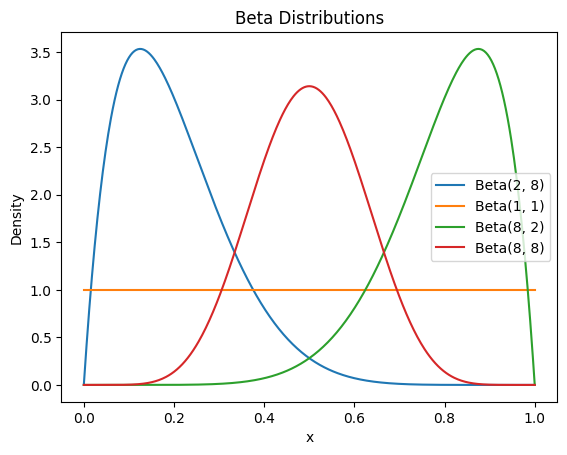

In [123]:
# Beta pdf
def beta_pdf(x, a, b):
    B = math.gamma(a) * math.gamma(b) / math.gamma(a + b)
    return (x**(a - 1)) * ((1 - x)**(b - 1)) / B

# Grid
x = np.linspace(0, 1, 500)

# Compute distributions
y1 = beta_pdf(x, 2, 8)
y2 = beta_pdf(x, 1, 1)
y3 = beta_pdf(x, 8, 2)
y4 = beta_pdf(x, 8, 8)

# Plot
plt.figure()
plt.plot(x, y1, label="Beta(2, 8)")
plt.plot(x, y2, label="Beta(1, 1)")
plt.plot(x, y3, label="Beta(8, 2)")
plt.plot(x, y4, label="Beta(8, 8)")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Beta Distributions")
plt.legend()
plt.show()

In [124]:
def thompson_sampling(bandit, T=2000):

    K = bandit.K    # predetermined 

    # Allocate space
    alphas = np.ones(K)
    betas = np.ones(K)
    rewards = np.zeros(T)
    arms_played = np.zeros(T, dtype=int)
    
    # Thompson sampling
    for t in range(T):

        # Sample K-dim "scores" from Beta(alpha_a, beta_a)
        samples = np.random.beta(alphas, betas)

        # Choose the highest one
        arm = np.argmax(samples)  # outputs an index (0, 1, ..., K-1)
        
        reward = bandit.pull(arm)  # outputs 1 or 0
        
        alphas[arm] += reward       # Update successes
        betas[arm] += (1 - reward)  # Update failures 
        
        # Store rewards and the indecies
        rewards[t] = reward
        arms_played[t] = arm
    
    return rewards, arms_played

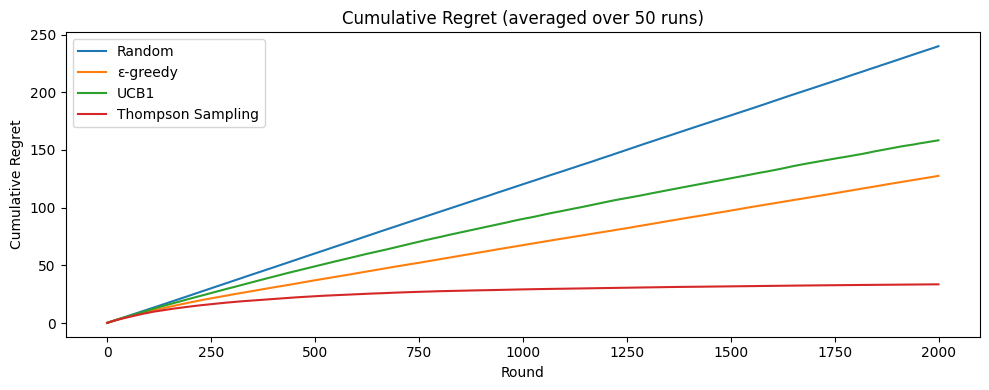

In [141]:
np.random.seed(42)  # Fix rng (for fair comparison)

T = 2000
n_runs = 50
p_star = bandit.expected_reward(bandit.optimal_arm())

# Cretae a dictionary with the functions defined above
algorithms = {
    "Random": run_random,
    "ε-greedy": lambda b, T: epsilon_greedy(b, T, epsilon=0.5),
    "UCB1": lambda b, T: ucb1(b, T, c=2.0),
    "Thompson Sampling": thompson_sampling,
}

# Plot the results
plt.figure(figsize=(10, 4))

for name, algo in algorithms.items():  # For each algorithm

    # Allocate space for regrets
    all_regrets = np.zeros((n_runs, T))

    # For each repetition
    for run in range(n_runs):

        # Get the arms given by each algorithm
        _, arms = algo(bandit, T)

        # Compute per round regret
        per_round = p_star - np.array([bandit.expected_reward(a) for a in arms])

        # Compute cumulative regrets
        all_regrets[run] = np.cumsum(per_round)

    # Take the mean across 
    mean_regret = all_regrets.mean(axis=0) # axis=0 <=> over n_runs
    
    # Plot the results
    plt.plot(mean_regret, label=name)

plt.xlabel("Round")
plt.ylabel("Cumulative Regret")
plt.title("Cumulative Regret (averaged over 50 runs)")
plt.legend()
plt.tight_layout()
plt.show()

**(1c)** Answer the following in 2–3 sentences each (no code needed):

1.  Which of the three algorithms learns fastest (achieves lowest
    cumulative regret)? Why does it outperform the others?

2.  A marketing manager proposes: *“Let’s just test each of the 5
    channels equally for 400 rounds each, then pick the winner.”* What
    is the cumulative regret of this uniform-testing strategy over the
    full $T = 2000$ rounds, and why do adaptive algorithms do better?

**Solution:**

1.  **Thompson Sampling** typically achieves the lowest cumulative
    regret. It outperforms the others because it directs exploration
    toward arms that are *plausibly optimal* — uncertain arms that might
    be the best — rather than exploring uniformly at random
    ($\epsilon$-greedy) or using a deterministic upper bound that can
    over-explore (UCB1). As the posterior concentrates around the true
    rates, Thompson Sampling naturally shifts almost entirely to
    exploitation.

2.  Under uniform testing, each of the four suboptimal arms is pulled
    400 times. The cumulative regret is
    $\sum_{k \neq k^*} 400 \cdot (p^* - p_k) = 400(0.17 + 0.10 + 0.13 + 0.20) = 240$.
    This is the same regret as the purely random policy, because both
    allocate equal trials to each arm over the full horizon. Adaptive
    algorithms achieve far less regret (typically $< 50$) because they
    learn within the first few hundred rounds to concentrate pulls on
    the best arm, rather than wasting budget on channels that are
    clearly inferior.


# Problem 2: Airline Revenue Management via Reinforcement Learning

In Problem 1 the firm chose prices without state — each round was
independent. 

Real pricing problems are richer: an airline has a *finite*
number of seats and a *finite* selling horizon, so today’s optimal fare
depends on how many seats remain and how many days are left before
departure. (Other examples?)

This kind of sequential decision-making under uncertainty is
formalised as a **Markov Decision Process (MDP)**, defined by states
$\mathcal{S}$ (what the agent observes), actions $\mathcal{A}$ (what it
can do), a reward function $R(s,a)$ (immediate payoff), transition
probabilities $P(s'\mid s,a)$ (how the world evolves), and a discount
factor $\gamma\in[0,1]$ (how much the agent values future versus present
rewards).

![Slot machines dist](./mdp.png)


The key recursive insight is the **Bellman equation**:
$$V(s)=\max_a\bigl[\mathbb{E}[r\mid s,a]+\gamma\,\mathbb{E}[V(s')\mid s,a]\bigr].$$


When the model ($P$ and $R$) is known, **value iteration** applies this
equation to every state until convergence, yielding the optimal policy
$\pi^*(s)=\arg\max_a[\cdots]$. 

When the model is *unknown*, **Q-learning** learns action-values directly from data using the update $Q(s,a)\leftarrow Q(s,a)+\alpha\bigl[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\bigr]$ — the agent simply interacts with the environment and refines its
estimates, requiring no knowledge of $P$ or $R$.


### Remarks and Intuition

Reinforcement Learning is about **planning under uncertainty**. An agent repeatedly interacts with an environment, choosing actions and receiving rewards. One key question we want to answer is "How good is it to be in a particular state?".

Value function answers this by providing the **value** of each state: the expected total future reward if the agent behaves optimally.

Value iteration can be used to find the value function. At its core, value iteration is a method for finding a **fixed point** of a particular function.



#### The Idea of a Fixed Point

A **fixed point** of a function $f$ is a value $x$ such that

$$
x = f(x)
$$

In other words, applying the function does not change the value.

**A Simple Fixed-Point Example**

Consider the equation

$$
x = 1 + 0.5x
$$

We want to find a value of $x$ that satisfies this equation.

Solving algebraically:

$$
x - 0.5x = 1
$$

$$
0.5x = 1
$$

$$
x = 2
$$

So $x = 2$ is the fixed point.

Instead of solving the equation directly, we can **approach the solution iteratively**.

Start with an arbitrary guess:

$$
x_0 = 0
$$

Then repeatedly apply the function

$$
x_{k+1} = 1 + 0.5x_k
$$

This produces the sequence

$$
x_1 = 1
$$

$$
x_2 = 1.5
$$

$$
x_3 = 1.75
$$

$$
x_4 = 1.875
$$

and so on. The sequence converges toward

$$
x = 2
$$

So by repeatedly applying the function, we get closer and closer to the fixed point.

### Contraction Mappings

Why does this process converge?

Because the function

$$
f(x) = 1 + 0.5x
$$

is a **contraction mapping**.

A function $f$ is a contraction if it shrinks the distance between inputs:

$$
|f(x) - f(y)| \le c |x - y|
$$

for some constant $c < 1$.

For our example,

$$
f(x) = 1 + 0.5x
$$

we have

$$
|f(x) - f(y)| = |0.5(x - y)| = 0.5|x - y|
$$

Since $0.5 < 1$, each application of $f$ **reduces the error** between the current estimate and the fixed point.

Because the function keeps shrinking distances, repeatedly applying it must converge to a **unique fixed point**.


### Connecting This to Value Iteration

Value iteration follows exactly the same idea, but instead of a single number we update a **value function over states**.

Define the **Bellman operator** (operator means a function of a function)

$$
(TV)(s) =
\max_a
\sum_{s'} P(s'|s,a)
\left[
R(s,a,s') + \gamma V(s')
\right]
$$

This operator takes a value function $V$ and produces a new one.

The key result is that the Bellman operator is a **contraction mapping** with contraction factor $\gamma$.

Value iteration repeatedly applies this operator:

$$
V_{k+1} = T V_k
$$

Starting from an arbitrary initial value function $V_0$, we update it again and again:

$$
V_1 = T V_0
$$

$$
V_2 = T V_1
$$

$$
V_3 = T V_2
$$

Each update moves the estimate closer to the true optimal value function.

Eventually the sequence converges to

$$
V^*
$$

which satisfies the **Bellman optimality equation**

$$
V^* = T V^*
$$

This means the optimal value function is exactly the **fixed point of the Bellman operator**.


**Recommended readings:** 

* Csaba Szepesvari, Algorithms for Reinforcement Learning: Appendix A1, A2 (Math and proofs)

* Stanford CS234 [lecture videos](https://www.youtube.com/watch?v=FgzM3zpZ55o&list=PLoROMvodv4rOSOPzutgyCTapiGlY2Nd8u) (Intuition and algorithms)

## Environment

The `AirlinePricingEnv` below models an airline selling $N=10$ seats on
a flight departing in $T=25$ days (a small state space so that tabular
Q-learning can learn a policy close to the optimal one). 

Each day the airline chooses one of five fare classes. One potential passenger
arrives and buys (or not) according to a logit demand model — the same
functional form as PS2’s discrete choice, with $P(\text{buy})=\frac{1}{1+\exp(-(\alpha+\beta\cdot\text{price}))}$.

First we need to define our environment as we didi in the last example using a `AdChannellBandit` class. Only this time the it will look more complicated.

The `gymnasium` library is an RL environment API (successor to OpenAI Gym).

The `spaces` module is how you formally describe what observations and actions look like. 

In [126]:
import gymnasium
from gymnasium import spaces

class AirlinePricingEnv(gymnasium.Env):
    """Airline revenue management environment.

    State: (seats_remaining, days_to_departure)
    Action: one of 5 fare classes
    Reward: fare if passenger buys, 0 otherwise
    Terminal: departure day reached or sold out

    Default: 10 seats, 25 days (small state space so Q-learning can match VI well).
    """

    def __init__(self, max_seats=10, max_days=25, alpha=5.0, beta=-0.02):
        
        super().__init__()  # calls methods the parent class

        self.max_seats = max_seats  # starting seats
        self.max_days = max_days  # starting time horizon
        self.alpha = alpha       # logit param
        self.beta = beta         # logit param (control demand success prob.)
        
        self.fares = np.array([100, 200, 300, 400, 500]) # Actions

        # Each state obs. is a 2-dim vec. of integers (seats_left, days_left)
        # Specify seats_left = 1, ..., max_seats, days_left = 1, ..., max_days
        # MultiDiscrete(n) represents values in the range {0, ..., n-1}, so add 1
        # This will create all possible (seats, days) tuples 
        # The state space is {0, 1, ..., 10} x {0, 1, ..., 25} 
        self.observation_space = spaces.MultiDiscrete([max_seats + 1, max_days + 1])

        # Same as above, specify actions = 100 or 200 or ... 500.
        self.action_space = spaces.Discrete(len(self.fares))

    # define the demand function (probabilistic)
    def demand_prob(self, price):
        """P(buy) = 1 / (1 + exp(-(alpha + beta * price)))"""
        return 1.0 / (1.0 + np.exp(-(self.alpha + self.beta * price)))

    # initializes the environment
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.seats_remaining = self.max_seats
        self.days_to_departure = self.max_days
        
        # Returns initial observation, empty info dict.
        return self._get_obs(), {}

    # Shows the current state vector
    # (at each iteration state changes and is stored in the class)
    def _get_obs(self):
        return np.array([self.seats_remaining, self.days_to_departure])

    # define how actions are taken
    def step(self, action):
        
        # You act by choosing a price
        price = self.fares[action]

        # If there are seats available
        if self.seats_remaining > 0:

            # Consumer observe your price and buys or not
            p = self.demand_prob(price)
            bought = int(self.np_random.binomial(1, p))

            # Reward is your profit
            reward = float(price * bought)

            # Update the state
            self.seats_remaining -= bought

        else:

            # If there are no seats, there is no reward
            reward = 0.0

        # Update the model (one customer comes each days in this simple model)
        self.days_to_departure -= 1

        # Terminate if conditions are met
        terminated = (self.days_to_departure == 0) or (self.seats_remaining == 0)
        
        # Step was completed successfully (wasn't stopped artificially)
        truncated = False

        # Returns the state, rewars, bools, and info dict (standard for Gymnasium)
        return self._get_obs(), reward, terminated, truncated, {}


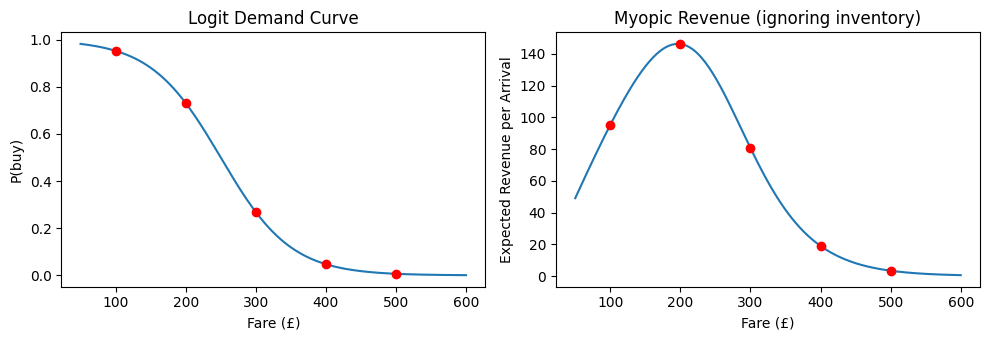

Observation space: MultiDiscrete([11 26])
Action space:      Discrete(5)  (fares = [100 200 300 400 500])
Purchase probs:    {100: 0.953, 200: 0.731, 300: 0.269, 400: 0.047, 500: 0.007}


In [127]:
# Create the environment
env = AirlinePricingEnv()

# Plot the demand and the revenue
price_grid = np.linspace(50, 600, 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(price_grid, env.demand_prob(price_grid))
axes[0].scatter(env.fares, env.demand_prob(env.fares), c='red', zorder=5)
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('P(buy)')
axes[0].set_title('Logit Demand Curve')

axes[1].plot(price_grid, price_grid * env.demand_prob(price_grid))
axes[1].scatter(env.fares, env.fares * env.demand_prob(env.fares), c='red', zorder=5)
axes[1].set_xlabel('Fare (£)')
axes[1].set_ylabel('Expected Revenue per Arrival')
axes[1].set_title('Myopic Revenue (ignoring inventory)')
plt.tight_layout()
plt.show()

# Print env info 
print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}  (fares = {env.fares})")
print(f"Purchase probs:    {dict(zip(env.fares, np.round(env.demand_prob(env.fares), 3)))}")

**(2a) MDP formulation.** Write down the components of this MDP:

1.  State space $\mathcal{S}$: what variables define a state? How large
    is $|\mathcal{S}|$?
2.  Action space $\mathcal{A}$: what does the agent choose?
3.  Reward $R(s,a)$: what is the expected immediate reward?
4.  Transition $P(s'\mid s,a)$: given the Bernoulli demand, what are the
    possible next states and their probabilities?
5.  What economic interpretation does the discount factor $\gamma$ have
    here?
6.  When does an episode terminate?

**Solution:**

1.  **State space:**
    $\mathcal{S} = \{0,\ldots,10\}\times\{0,\ldots,25\}$ — all pairs
    $(\text{seats\_remaining},\,\text{days\_to\_departure})$. Size:
    $11\times 26 = 286$.

2.  **Action space:** $\mathcal{A}=\{0,1,2,3,4\}$ corresponding to fares
    $\{100,200,300,400,500\}$.

3.  **Reward:** $\mathbb{E}[R\mid s,a] = \text{fare}_a \cdot p_a$ where
    $p_a = \sigma(\alpha + \beta\cdot\text{fare}_a)$. The reward depends
    on the action but not on the state (except that the episode is
    terminal when $n=0$).

4.  **Transition:** From state $(n,d)$ with $n\ge 1$, choosing action
    $a$:

    -   With probability $p_a$: next state is $(n{-}1,\,d{-}1)$
        (passenger buys).
    -   With probability $1-p_a$: next state is $(n,\,d{-}1)$ (no
        purchase).

5.  **Discount factor:** $\gamma$ captures the time value of money —
    revenue today is worth more than revenue tomorrow. With
    $\gamma=0.99$ over 50 periods, $\gamma^{50}\approx 0.61$.

6.  **Terminal conditions:** $d=0$ (departure) or $n=0$ (sold out).

**(2b) Value iteration (known demand).** Suppose the airline knows the
demand function (i.e. it knows $\alpha$ and $\beta$). Implement value
iteration to compute the optimal value function and policy. For
non-terminal states $(s,d)$ with $s\ge 1,\,d\ge 1$:

$$V(s,d) = \max_a\left[p_a\bigl(\text{fare}_a + \gamma\,V(s{-}1,\,d{-}1)\bigr) + (1-p_a)\,\gamma\,V(s,\,d{-}1)\right]$$

where $p_a = P(\text{buy}\mid\text{fare}_a)$. Sweep over all states
until $\max_{s,d}|V^{\text{new}}-V^{\text{old}}|<\texttt{tol}$. Then
plot the optimal fare as a heatmap over
$(\text{seats\_remaining},\,\text{days\_to\_departure})$.

``` python
def value_iteration(env, gamma=0.99, tol=1e-6):
    """Compute optimal V and policy by value iteration.

    Returns:
        V: np.array shape (max_seats+1, max_days+1)
        policy: np.array shape (max_seats+1, max_days+1), optimal action index
    """
    pass
```

**Solution:**

In [ ]:
def value_iteration(env, gamma=0.99, tol=1e-6):

    # Get the env. info
    S, D = env.max_seats + 1, env.max_days + 1
    n_actions = len(env.fares)
    probs = env.demand_prob(env.fares)

    # Initialise
    V = np.zeros((S, D))

    while True: # inf. loop will break once the value function converges
        
        # initialise a metric for convergence status
        delta = 0.0
        
        # Iterate over all states
        for s in range(1, S):
            for d in range(1, D):

                # Record the V old value (for later comparison)
                v_old = V[s, d]

                # initialise the best action value
                best = -np.inf

                # Iterate over all actions (cond. on state vector)
                for a in range(n_actions):

                    # Get the prob. of purchase
                    p = probs[a]

                    # Compute the value function (conditional on states)
                    val = p * (env.fares[a] + gamma * V[s - 1, d - 1]) \
                        + (1 - p) * gamma * V[s, d - 1]
                    
                    # Maximize over actions
                    # (If were stored in an array, can use np.max instead)
                    if val > best:   # This will be update only when the new a is better
                        best = val
                    
                # Update the value function
                V[s, d] = best

                # Update the metric for convergence status
                delta = max(delta, abs(V[s, d] - v_old))

        # If the tolerance is met, exit the loop
        if delta < tol:
            break

    # The best policy is the one that maximizes the value function 
    # After the value function is given (not the only way to compute)

    # Allocate space
    policy = np.zeros((S, D), dtype=int)

    # Iterate over all states
    for s in range(1, S):
        for d in range(1, D):

            # Initialise
            best_a, best_val = 0, -np.inf

            # Iterate over all actions 
            for a in range(n_actions):
                p = probs[a]
                val = p * (env.fares[a] + gamma * V[s - 1, d - 1]) \
                    + (1 - p) * gamma * V[s, d - 1]
                
                # Maximize the value function w.r.t. actions
                if val > best_val: # This will be update only when the new a is better
                    best_val = val
                    best_a = a
            
            # Store the best action
            policy[s, d] = best_a

    # Return the value and policy functions
    return V, policy



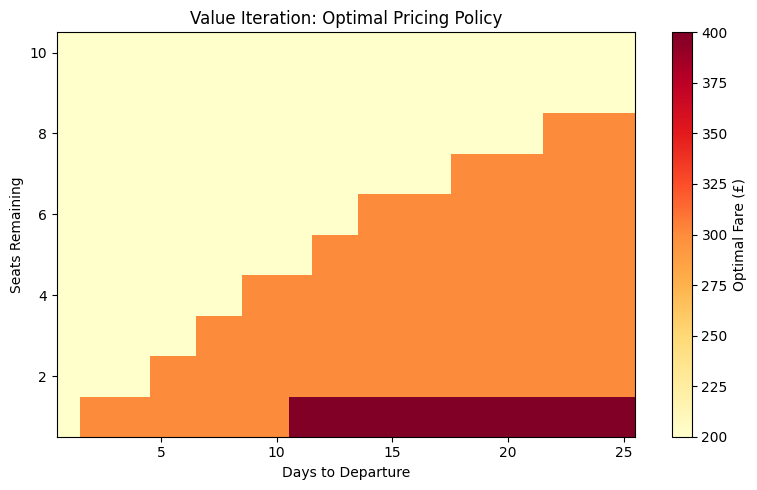

Value of starting state V(10, 25) = £2149


In [ ]:
# Run value iteration 
V_star, pi_star = value_iteration(env)

# Plot the results
fare_map = np.array(env.fares)[pi_star]
plt.figure(figsize=(8, 5))
im = plt.imshow(fare_map[1:, 1:], origin='lower', aspect='auto',
                extent=[0.5, env.max_days + 0.5, 0.5, env.max_seats + 0.5],
                cmap='YlOrRd')
plt.colorbar(im, label='Optimal Fare (£)')
plt.xlabel('Days to Departure')
plt.ylabel('Seats Remaining')
plt.title('Value Iteration: Optimal Pricing Policy')
plt.tight_layout()
plt.show()

print(f"Value of starting state V({env.max_seats}, {env.max_days}) = £{V_star[env.max_seats, env.max_days]:.0f}")

**(2c) Q-learning (unknown demand).** Now suppose the airline does *not*
know the demand function. Implement tabular Q-learning with
$\epsilon$-greedy exploration. Train for **10,000 episodes** and use
**decaying exploration**:
e.g. $\epsilon = \max(0.01,\, 0.4 - \text{episode}/12000)$ so that the
agent explores less as it learns. Plot the learning curve (episode
reward smoothed over 100 episodes).

$$Q(s,a) \leftarrow Q(s,a) + \alpha\bigl[r + \gamma\max_{a'}Q(s',a') - Q(s,a)\bigr]$$

``` python
def q_learning(env, n_episodes=10000, alpha=0.1, gamma=0.99, epsilon_start=0.4, epsilon_end=0.01):
    """Tabular Q-learning with epsilon-greedy exploration.

    Returns:
        Q: dict mapping (seats, days, action) -> value
        episode_rewards: list of total reward per episode
    """
    pass
```

**Solution:**

In [ ]:
def q_learning(env, n_episodes=10_000, alpha=0.1, gamma=0.99, epsilon_start=0.4, epsilon_end=0.01):
    
    Q = {}  # dictionary to store Q-values: keys = (seats, days, action)
    episode_rewards = []   # track total reward per episode

    # return Q-value given the (s, d, a) or 0 if unseen state-action
    def get_q(s, d, a):
        return Q.get((s, d, a), 0.0)

    # Repeat `n_episodes` times
    for ep in range(n_episodes):

        # Update the exploration rate
        epsilon = max(epsilon_end, epsilon_start - ep / 12000)

        # Initialise (start over every time)
        obs, _ = env.reset()
        seats, days = int(obs[0]), int(obs[1])
        total_reward = 0.0
        terminated = False

        # Instead of while True, can terminate (i.e. die early...)
        while not terminated:

            # Choose action (epsilon-greedy alg.)
            if np.random.random() < epsilon:
                action = env.action_space.sample()   # random action (explore)
            else:
                q_vals = [get_q(seats, days, a) for a in range(env.action_space.n)]
                action = int(np.argmax(q_vals))   # greedy action (exploit)

            # Take action in environment
            next_obs, reward, terminated, truncated, _ = env.step(action)
            next_seats, next_days = int(next_obs[0]), int(next_obs[1])
            total_reward += reward  # Update the reward

            # Compute and update Q-value
            best_next = 0.0 if terminated else max(
                get_q(next_seats, next_days, a) for a in range(env.action_space.n)
            )
            td_target = reward + gamma * best_next
            Q[(seats, days, action)] = get_q(seats, days, action) \
                + alpha * (td_target - get_q(seats, days, action))

            # Update the state values 
            seats, days = next_seats, next_days

            # Repeate!!!

        # Store the reward for each episode
        episode_rewards.append(total_reward)

    # Return the Q values and list of rewards (for each episode)
    return Q, episode_rewards


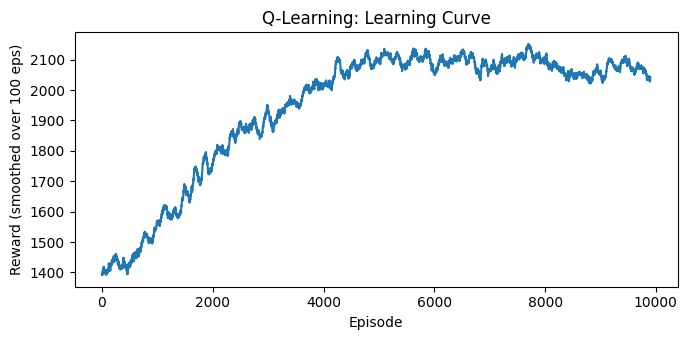

Mean reward (last 500 episodes): £2068


In [131]:
# Run the Q-learning algorithm
Q_table, ep_rewards = q_learning(env, n_episodes=10000)

# Smooth the rewards (use MA) and plot the results
window = 100
smoothed = np.convolve(ep_rewards, np.ones(window) / window, mode='valid')

plt.figure(figsize=(7, 3.5))
plt.plot(smoothed)
plt.xlabel('Episode')
plt.ylabel(f'Reward (smoothed over {window} eps)')
plt.title('Q-Learning: Learning Curve')
plt.tight_layout()
plt.show()

print(f"Mean reward (last 500 episodes): £{np.mean(ep_rewards[-500:]):.0f}")

**(2d) Compare policies.** Extract the greedy policy from Q (for each
state, the action with highest Q-value) and plot it as a heatmap
side-by-side with the value-iteration policy from (2b). How closely does
Q-learning recover the optimal policy? When would you prefer each
approach? (If the two heatmaps look very different, try training
Q-learning for more episodes or using a decaying $\epsilon$ so that
exploration decreases over time.)

**Solution:**

/var/folders/5w/kzd6klcd6b7g536lbknh745m0000gn/T/ipykernel_8434/3092157071.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


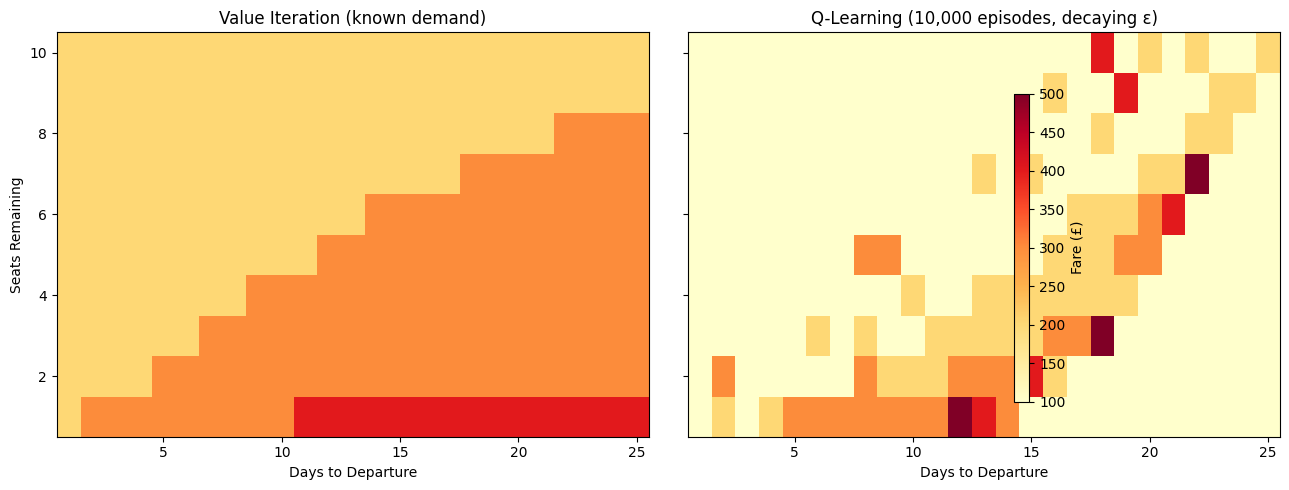

Policy agreement: 10.4% of states match


In [132]:
# Allocate space
q_policy = np.zeros((env.max_seats + 1, env.max_days + 1), dtype=int)

# Iterate over each state (s, d)
for s in range(1, env.max_seats + 1):
    for d in range(1, env.max_days + 1):

        # store the action with the highest Q-value
        q_vals = [Q_table.get((s, d, a), 0.0) for a in range(env.action_space.n)]
        q_policy[s, d] = np.argmax(q_vals)

# indices -> fares
q_fare_map = np.array(env.fares)[q_policy]
vi_fare_map = np.array(env.fares)[pi_star]

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

im0 = axes[0].imshow(vi_fare_map[1:, 1:], origin='lower', aspect='auto',
                      extent=[0.5, env.max_days + 0.5, 0.5, env.max_seats + 0.5],
                      cmap='YlOrRd', vmin=100, vmax=500)
axes[0].set_xlabel('Days to Departure')
axes[0].set_ylabel('Seats Remaining')
axes[0].set_title('Value Iteration (known demand)')

im1 = axes[1].imshow(q_fare_map[1:, 1:], origin='lower', aspect='auto',
                      extent=[0.5, env.max_days + 0.5, 0.5, env.max_seats + 0.5],
                      cmap='YlOrRd', vmin=100, vmax=500)
axes[1].set_xlabel('Days to Departure')
axes[1].set_title('Q-Learning (10,000 episodes, decaying ε)')

fig.colorbar(im1, ax=axes, label='Fare (£)', shrink=0.8)
plt.tight_layout()
plt.show()

agreement = np.mean(pi_star[1:, 1:] == q_policy[1:, 1:])
print(f"Policy agreement: {agreement:.1%} of states match")

**Discussion.** Both policies share the same broad structure: charge
higher fares when seats are scarce relative to remaining time, and lower
fares when inventory is plentiful. Q-learning’s policy is noisier —
particularly in rarely-visited states — because it must *discover* the
demand function through trial and error, while value iteration exploits
exact knowledge of $P(\text{buy}\mid\text{fare})$.

This parallels a classic distinction in structural econometrics. Rust
(1987) solved Harold Zurcher’s bus-engine replacement problem by
assuming the agent knows the transition model and solving the Bellman
equation — exactly what value iteration does in (2b). Q-learning takes
the model-free approach: no assumptions about demand, learning purely
from observed outcomes. The structural (model-based) approach gives the
exact optimum when the model is correctly specified; Q-learning is more
robust when the demand model is misspecified or unknown, at the cost of
requiring more data and producing noisier policies.

# Problem 3: Deep Q-Networks for Content Personalisation

In Problem 2, tabular Q-learning worked because every (inventory, time)
state could be visited many times. 

But most real applications have states that are high-dimensional or continuous — think of a user’s full browsing history or click pattern across dozens of content categories.

We cannot store a separate Q-value for every possible state.

**Deep Q-Networks (DQN)** solve this by replacing the Q-table with a
neural network $Q_\theta(s, a)$ that takes a state vector as input and
outputs Q-values for all actions. 

Because the network *generalises* across similar states, it can estimate Q-values for states never seen during training. 

Two techniques stabilise learning: a **replay buffer** (stores past transitions and samples random mini-batches to break temporal correlation) and a **target network** (a slowly-updated copy of $Q_\theta$ used to compute Bellman targets, preventing the “moving target” problem). 

We apply DQN to within-session content personalisation: a platform must learn each visitor’s preferences during a single browsing session by observing their clicks, then serve content that maximises conversion.

**Remarks**

* Replay buffer: A technique used in many reinforcement learning algorithms, especially **Deep Q-Networks (DQN)**, to improve training stability and efficiency.


    When an agent interacts with an environment, consecutive states are highly correlated:

    $$
    s_t, s_{t+1}, s_{t+2}, \dots
    $$

    Neural networks generally assume that training data is **independent and identically distributed (i.i.d.)**. Training on correlated samples can cause unstable learning.

    Replay buffers solve this by **randomizing the training data** through sampling.

    Instead of learning directly from the most recent experience, the agent **stores past experiences in a memory buffer** and later **samples from this buffer to train the model**.

* Target Networks: Another stabilization technique used in deep reinforcement learning which stabilizes the Q-learning updates.


    Typically, the target network is updated by copying parameters from the online network every fixed number of steps:

    $$
    \theta^- \leftarrow \theta
    $$

    This means the target values remain **temporarily fixed**, giving the optimization process a more stable objective.

    Another common approach is **soft updates**:

    $$
    \theta^- \leftarrow \tau \theta + (1-\tau)\theta^-
    $$

    where $0 < \tau \ll 1$.


These techniques were key innovations that made **Deep Q-Networks (DQN)** train successfully with neural networks.

## Environment

In [133]:
from itertools import combinations  # Used to generate all possible category sets

list(combinations(['red', 'blue', 'green'], 2))

[('red', 'blue'), ('red', 'green'), ('blue', 'green')]

In [134]:
list(combinations(["Tech", "Fashion", "Sports", "Food", "Travel"], 3))


# Choose 3 from 5 = 5! / 3! 2! = 5 * 2 = 10

[('Tech', 'Fashion', 'Sports'),
 ('Tech', 'Fashion', 'Food'),
 ('Tech', 'Fashion', 'Travel'),
 ('Tech', 'Sports', 'Food'),
 ('Tech', 'Sports', 'Travel'),
 ('Tech', 'Food', 'Travel'),
 ('Fashion', 'Sports', 'Food'),
 ('Fashion', 'Sports', 'Travel'),
 ('Fashion', 'Food', 'Travel'),
 ('Sports', 'Food', 'Travel')]

In [135]:
import gymnasium                  
from gymnasium import spaces       # Used to describe observation/action formats
from itertools import combinations  # Used to generate all possible category sets
from scipy.special import expit     # The logistic sigmoid function
import numpy as np                  

class ContentPersonalizationEnv(gymnasium.Env):
    """
    Within-session content personalisation.

    A platform displays K=3 of M=5 content categories at each page view.
    The visitor (one of 3 latent types) clicks according to an MNL model
    over the displayed categories plus an outside option.  At session end,
    conversion probability depends on how well displayed content matched
    the visitor's true preferences.
    """

    CATEGORIES = ["Tech", "Fashion", "Sports", "Food", "Travel"]
    TYPE_NAMES = ["Tech enthusiast", "Fashionista", "Sports fan"]

    TYPE_UTILITIES = np.array([
        [2.0, 0.2, 0.5, 0.3, 0.8],   # Type 0
        [0.3, 2.0, 0.2, 0.8, 1.0],   # Type 1
        [0.5, 0.3, 2.0, 0.5, 0.2],   # Type 2
    ])

    OUTSIDE_UTILITY = 0.5   # User skips clicking anything

    def __init__(self, max_steps=8):
        super().__init__()
        self.max_steps = max_steps  # Maximum number of page views (steps) per session
        self.n_categories = 5

        # Generate all possible combinations of 3 categories out of 5
        # Each combination represents one action the agent can take
        self.assortments = list(combinations(range(5), 3))

        # Define the observation space:
        # A 7-dimensional continuous vector containing:
        #  -  click counts for each of 5 categories
        #  -  skip count
        #  -  remaining steps
        self.observation_space = spaces.Box(
            low=0.0, high=np.inf, shape=(7,), dtype=np.float32
        )

        # Each action corresponds to selecting one assortment of 3 categories
        self.action_space = spaces.Discrete(len(self.assortments))

    def reset(self, seed=None, options=None):  # Reset the environment, initialise
        super().reset(seed=seed)
        self.visitor_type = self.np_random.integers(3)
        self.utilities = self.TYPE_UTILITIES[self.visitor_type]
        self.click_counts = np.zeros(self.n_categories)
        self.skip_count = 0
        self.steps_remaining = self.max_steps
        return self._get_obs(), self._get_info()

    # Helper method to construct observation vector
    def _get_obs(self):
        return np.array([
            *(self.click_counts / self.max_steps),  # Normalized click counts for each category
            self.skip_count / self.max_steps,       # Normalized skip counts
            self.steps_remaining / self.max_steps,  # Fraction of steps remaining
        ], dtype=np.float32)

    # Helper method that returns info dict
    def _get_info(self):
        return {"visitor_type": self.visitor_type,
                "type_name": self.TYPE_NAMES[self.visitor_type]}

    # Given an action execute `action`
    def step(self, action):

        # action is an index, convert to type names
        assortment = self.assortments[action]

        # MNL choice over displayed categories + outside option
        utils = np.array([self.utilities[j] for j in assortment])
        exp_utils = np.exp(utils)
        exp_outside = np.exp(self.OUTSIDE_UTILITY)
        denom = exp_utils.sum() + exp_outside

        # Final probability vector including all categories and the outside option
        probs = np.append(exp_utils / denom, exp_outside / denom)

        # Sample the user's choice according to the MNL probabilities
        #  If the user clicked a displayed category
        choice = self.np_random.choice(len(probs), p=probs)  
        if choice < len(assortment):
            # Increment click count for that category
            self.click_counts[assortment[choice]] += 1
        else:
            # Otherwise increment skip counter
            self.skip_count += 1

        # Update remaining steps
        self.steps_remaining -= 1
        # Check if the session has ended
        terminated = self.steps_remaining == 0

        # Compute the reward
        reward = 0.0 # Initialize 
        if terminated:

            # Identify the visitor's two most preferred categories
            top2 = np.argsort(self.utilities)[-2:]
            
            # Compute a match score (fraction of clicks on preferred categories)
            total_clicks = self.click_counts.sum() # Total clicks
            clicks_on_top2 = self.click_counts[top2].sum() # Top clicks
            match_score = clicks_on_top2 / max(1, total_clicks)

            # Convert the score into probabilities
            conversion_prob = expit(3 * match_score - 1.5)

            # Sample a binary conversion outcome (1 if conversion happens)
            reward = float(self.np_random.random() < conversion_prob)

        # Return new observation, reward, termination flag, truncation flag, and info
        return self._get_obs(), reward, terminated, False, self._get_info()


In [136]:

env = ContentPersonalizationEnv()

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space} ({len(env.assortments)} assortments)\n")

print("Assortments (category indices):")
for i, a in enumerate(env.assortments):
    cats = [env.CATEGORIES[j] for j in a]
    print(f"  Action {i}: {a} = {cats}")

print(f"\nVisitor types and MNL utilities:")
for t in range(3):
    top2 = np.argsort(env.TYPE_UTILITIES[t])[-2:]
    top2_names = [env.CATEGORIES[j] for j in top2]
    print(f"  Type {t} ({env.TYPE_NAMES[t]}): {env.TYPE_UTILITIES[t]} -> top-2: {top2_names}")

Observation space: Box(0.0, inf, (7,), float32)
Action space: Discrete(10) (10 assortments)

Assortments (category indices):
  Action 0: (0, 1, 2) = ['Tech', 'Fashion', 'Sports']
  Action 1: (0, 1, 3) = ['Tech', 'Fashion', 'Food']
  Action 2: (0, 1, 4) = ['Tech', 'Fashion', 'Travel']
  Action 3: (0, 2, 3) = ['Tech', 'Sports', 'Food']
  Action 4: (0, 2, 4) = ['Tech', 'Sports', 'Travel']
  Action 5: (0, 3, 4) = ['Tech', 'Food', 'Travel']
  Action 6: (1, 2, 3) = ['Fashion', 'Sports', 'Food']
  Action 7: (1, 2, 4) = ['Fashion', 'Sports', 'Travel']
  Action 8: (1, 3, 4) = ['Fashion', 'Food', 'Travel']
  Action 9: (2, 3, 4) = ['Sports', 'Food', 'Travel']

Visitor types and MNL utilities:
  Type 0 (Tech enthusiast): [2.  0.2 0.5 0.3 0.8] -> top-2: ['Travel', 'Tech']
  Type 1 (Fashionista): [0.3 2.  0.2 0.8 1. ] -> top-2: ['Travel', 'Fashion']
  Type 2 (Sports fan): [0.5 0.3 2.  0.5 0.2] -> top-2: ['Food', 'Sports']


**(3a) Understanding DQN and running training.** The code below
implements a DQN agent: a **replay buffer** (stores past transitions and
samples random mini-batches to break correlation), a **target network**
(a copy of the Q-network updated every 10 episodes so that Bellman
targets do not change too quickly), and a **training loop** with
$\epsilon$-greedy exploration (decaying from 1.0 to 0.01 over 300
episodes).

Your task:

1.  **Implement the `QNetwork`** in PyTorch: input dimension 7 (state),
    two hidden layers of 128 units with ReLU, output dimension 10 (one
    Q-value per action). This is the only part you need to write.
2.  **Run the provided training loop** (it uses your `QNetwork` and the
    provided `ReplayBuffer`). Plot the learning curve (conversion rate
    over episodes).
3.  **Short answer:** Why do we use a replay buffer instead of updating
    on every single transition? Why do we use a separate target network
    instead of using the same network for both the current Q and the
    Bellman target?

``` python
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

class QNetwork(nn.Module):
    """Q-network: state (7-dim) -> hidden -> hidden -> Q-values (10 actions)."""
    def __init__(self, state_dim=7, n_actions=10):
        super().__init__()
        # TODO: define self.net as Sequential: Linear(7,128), ReLU, Linear(128,128), ReLU, Linear(128,10)
        pass

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """Stores (s, a, r, s', done) and samples random batches. Provided for you."""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones),
        )

    def __len__(self):
        return len(self.buffer)


# Run the training loop below after you have defined QNetwork above.
```

The training loop is provided in the solution so you can see the full
DQN algorithm (epsilon-greedy, Bellman update, target network sync).
Once your `QNetwork` is defined, the solution runs this loop and plots
the learning curve.

**Solution:**

**1. QNetwork:**

In [137]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque  # (fast append/pop) for implementing a replay buffer
import random

torch.manual_seed(42)

# Define a neural network class for approximating the Q-function
class QNetwork(nn.Module):
    def __init__(self, state_dim=7, n_actions=10): # Set input (state) size and output (action) size
        super().__init__()

        # Build the network as a simple feed-forward stack of layers
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    # Given an input, get the actions (using NNs)
    def forward(self, x):
        return self.net(x)

# Define an experience replay buffer for off-policy RL (e.g., DQN)
class ReplayBuffer:
    def __init__(self, capacity=10000):   # Set the maximum number of stored transitions
        self.buffer = deque(maxlen=capacity)  # Store transitions in a deque that auto-discards old items

    def push(self, state, action, reward, next_state, done):   # Add one transition to the buffer
        self.buffer.append((state, action, reward, next_state, done))    # Store transition as a tuple


    def sample(self, batch_size):         # Sample a random minibatch of transitions for training
        batch = random.sample(self.buffer, batch_size)    # Uniformly sample batch_size transitions
        states, actions, rewards, next_states, dones = zip(*batch)   # Unzip into separate tuples by field
        
        # Return tensors ready to be used by a PyTorch model
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones),
        )
    def __len__(self):  # For built-in behavior, buffer = ReplayBuffer() -> len(buffer) calls buffer.__len__()
        return len(self.buffer) # How many transitions are currently stored

**2. Training (full loop for reference):**

In [ ]:
# Create an instance of the (predefined) environment
env = ContentPersonalizationEnv()

# Create a trainable Q-network (before we had a table that we were updating, now it is a network)
q_net = QNetwork()

# Create the target Q-network used to stabilize training (like having another array for a stable iteration)
target_net = QNetwork()

# Initialize target network weights to match the online network (start from the same place (same initialization))
target_net.load_state_dict(q_net.state_dict())

# Define the Adam optimizer to update q_net parameters
optimizer = optim.Adam(q_net.parameters(), lr=1e-3)

# Create a replay buffer with space for 10,000 transitions
replay_buffer = ReplayBuffer(capacity=10_000)

n_episodes = 500   # Total number of training sessions to run
gamma = 0.99       # Discount factor for future rewards in Q-learning
batch_size = 32    # Minibatch size used for replay buffer
conversions = []   # Allocate space for per-episode conversion outcome (0/1 reward at end of episode)

for episode in range(n_episodes):

    # Linearly decay epsilon
    epsilon = max(0.01, 1.0 - episode / 300)

    # Reset environment at each iteration, get initial observation and info dict
    obs, info = env.reset()
    done = False   # This is a flag that we will set to True if the episode is terminated

    # Run the algorithm
    while not done:

        # Choose action according to epsilon-greedy algorithm
        if random.random() < epsilon:  # Explore
            action = env.action_space.sample()
        else:  # Exploit (greedy action)
            # Disable gradient tracking for action selection (faster)
            with torch.no_grad(): 
                # Compute Q-values (before we had a table giving a q-value for each (state, action) pair)
                # Now for each (multi-dimensional) state vector we get an array with dim = len(action) of q-vals
                q_vals = q_net(torch.FloatTensor(obs).unsqueeze(0))
                # Choose the action that maximizes the 
                action = q_vals.argmax(1).item()

        # Execute the action
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated  # Sets to true if is terminated or truncated

        # Store the observation (old states, new states, rewards, ...) in the replay buffer
        replay_buffer.push(obs, action, reward, next_obs, float(done))

        # Move to the next state for the following loop iteration
        obs = next_obs

        # Only train once we have enough samples to form a minibatch
        if len(replay_buffer) >= batch_size:
            
            # Sample a random minibatch of transitions
            s_b, a_b, r_b, ns_b, d_b = replay_buffer.sample(batch_size)

            # Get Q(s,a) for the taken actions using gather()
            current_q = q_net(s_b).gather(1, a_b.unsqueeze(1))
            # Compute the bootstrap target
            with torch.no_grad():
                # Compute max_a' Q_target(s', a') for each next state and the Bellman target
                next_q = target_net(ns_b).max(1)[0]
                target_q = r_b + gamma * next_q * (1 - d_b)

            # Compute MSE loss between predicted Q and target Q
            loss = nn.MSELoss()(current_q.squeeze(), target_q)
            # Update q_net parameters
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    conversions.append(reward) # Once terminated, record the final episode reward

    # Every 10 episodes, update the target network (copy online network weights into the target network)
    if episode % 10 == 0:
        target_net.load_state_dict(q_net.state_dict())


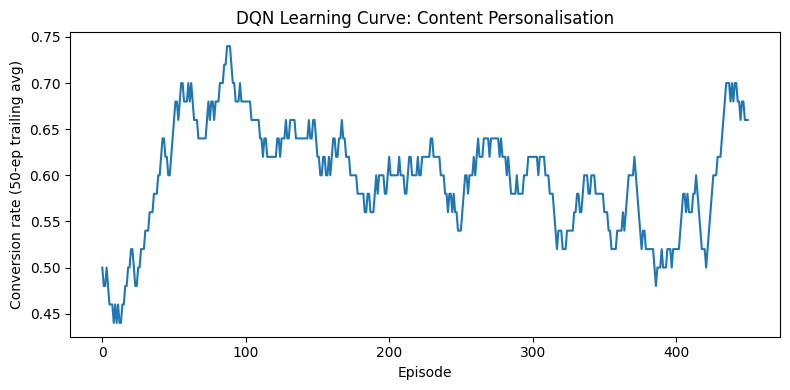

Final conversion rate (last 100 episodes): 0.590


In [139]:

# --- Plot learning curve ---
window = 50
smoothed = np.convolve(conversions, np.ones(window) / window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(smoothed)
plt.xlabel("Episode")
plt.ylabel(f"Conversion rate ({window}-ep trailing avg)")
plt.title("DQN Learning Curve: Content Personalisation")
plt.tight_layout()
plt.show()

print(f"Final conversion rate (last 100 episodes): {np.mean(conversions[-100:]):.3f}")

**3. Short answer — why replay buffer and target network?**

-   **Replay buffer:** Consecutive transitions
    $(s_t, a_t, r_t, s_{t+1})$ are strongly correlated (e.g. similar
    states). If we update the network only on the current transition,
    the gradient is biased by this correlation and learning can be
    unstable. Sampling *random* mini-batches from a buffer breaks this
    correlation and gives more i.i.d.-like updates, which stabilises
    training.

-   **Target network:** The Bellman target
    $r + \gamma \max_{a'} Q(s', a')$ depends on the same $Q$ we are
    updating. So the target moves with every step, making the learning
    target a “moving goalpost.” Using a separate network that is updated
    only every 10 episodes keeps the target fixed over many updates, so
    the agent can converge toward a stable target.

**(3b) Comparison with stable-baselines3.** The plot below compares our
DQN’s learning curve (from 3a) with one produced by the
`stable-baselines3` library (same environment, similar hyperparameters).
You do not need to run SB3 yourself.

Describe what the library implementation does differently from our
minimal DQN (e.g. loss function, gradient handling, exploration
schedule). Why might its curve look different from ours?

**Solution:**

Stable-baselines3’s DQN includes several refinements that our minimal
implementation in (3a) does not:

-   **Huber loss** instead of MSE for the Bellman error, which is less
    sensitive to large target outliers and can make learning more
    stable.
-   **Gradient clipping** (by norm) to prevent occasional large
    gradients from destabilising updates.
-   **Exploration schedule** defined over *timesteps* rather than
    episodes, with configurable linear decay.
-   **Double DQN** (optional): uses the current network to select the
    best next action and the target network to evaluate it, reducing
    overestimation of Q-values.
-   **Efficient replay sampling** and vectorised environments for faster
    training.

Because of these differences, the SB3 learning curve may converge faster
or to a slightly higher conversion rate, or look smoother. The main
takeaway is that production RL libraries add many small stabilisation
tricks on top of the core DQN idea (replay + target network).

*Optional:* If you have `stable-baselines3` installed, you can generate
a direct comparison by training SB3’s DQN on `ContentPersonalizationEnv`
for the same number of timesteps and plotting both curves. The code is
in the repository for reference.

**(3c)** Interpret the learned policy:

1.  For each visitor type, record which assortments the trained DQN
    selects during the **early** phase (steps 1–3) versus the **late**
    phase (steps 6–8). Does the agent explore early and exploit late?
2.  Compare the DQN’s conversion rate against a **static policy** that
    always displays the 3 globally most popular categories. How much
    does personalisation improve conversion?

**Solution:**

In [140]:
from collections import Counter  # Used to count frequency of actions later


n_eval = 200  # Number of evaluation episodes to run

# Allocate space for storing actions taken in different stages for each visitor type
type_early = {t: [] for t in range(3)}
type_late = {t: [] for t in range(3)}
dqn_conv = {t: [] for t in range(3)}

# Run evaluation episodes using the trained DQN policy
for _ in range(n_eval):

    # Reset environment at each eval session
    obs, info = env.reset()
    vtype = info["visitor_type"]  # Check the visitor type (0,1,2)

    # Initialize and run until termination
    step = 0
    done = False
    while not done:

        # Select the action with the highest predicted Q-value (using pre-trained Q-network)
        with torch.no_grad():
            action = q_net(torch.FloatTensor(obs).unsqueeze(0)).argmax(1).item()

        step += 1 # Increment step count

        # Record early actions (first few recommendations)
        if step <= 3:
            type_early[vtype].append(action)

        # Record later actions (toward the end of the interaction)
        if step >= 6:
            type_late[vtype].append(action)

        # Execute action in environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated # update the termination flag

    # Store final reward for this visitor type
    dqn_conv[vtype].append(reward)

# --- Static baseline: always show the top-3 globally popular categories ---

# Compute average utility of each category across visitor types
avg_utility = env.TYPE_UTILITIES.mean(axis=0)

# Select indices of the 3 most popular categories
top3_global = tuple(sorted(np.argsort(avg_utility)[-3:]))

# Convert category indices into readable category names and print
static_action = env.assortments.index(top3_global)
static_cats = [env.CATEGORIES[j] for j in top3_global]
print(f"Static policy: always show {static_cats} (action {static_action})\n")

# Store conversion rewards from the static policy
static_conv = {t: [] for t in range(3)}

# Evaluate the static baseline
for _ in range(n_eval):

    # Initialise
    obs, info = env.reset()
    vtype = info["visitor_type"]
    done = False

    # Run episode using the fixed static action
    while not done:
        obs, reward, terminated, truncated, info = env.step(static_action)
        done = terminated or truncated

    # Store the results
    static_conv[vtype].append(reward)

# --- Conversion comparison ---
print("Conversion rates by visitor type:")
print(f"{'Type':<20} {'DQN':>8} {'Static':>8} {'Lift':>8}")
print("-" * 46)
for t in range(3):
    d = np.mean(dqn_conv[t])                # Average conversion using DQN
    s = np.mean(static_conv[t])             # Average conversion using static baseline

    # Compute and print the percentage improvement of DQN over static baseline
    lift = (d - s) / max(s, 0.01) * 100
    print(f"{env.TYPE_NAMES[t]:<20} {d:>8.3f} {s:>8.3f} {lift:>+7.1f}%")

# Compute and print the overall conversion across all visitor types
d_all = np.mean([r for v in dqn_conv.values() for r in v])
s_all = np.mean([r for v in static_conv.values() for r in v])
print(f"{'Overall':<20} {d_all:>8.3f} {s_all:>8.3f} "
      f"{(d_all - s_all) / max(s_all, 0.01) * 100:>+7.1f}%")

# --- Action distributions: early vs late ---
print("\nMost frequent assortments by phase:")

# Compute conversion metrics for each visitor type
for t in range(3):
    print(f"\n  {env.TYPE_NAMES[t]}:")

    # Compare actions taken early vs late
    for label, actions in [("Steps 1-3", type_early[t]),
                           ("Steps 6-8", type_late[t])]:
        
        # Skip if no actions recorded
        if not actions:
            continue

        # Count most common actions (top 3)
        counts = Counter(actions).most_common(3)

        # Convert action indices into category names and compute percentages
        desc = "; ".join(
            f"{[env.CATEGORIES[j] for j in env.assortments[a]]} "
            f"({c / len(actions):.0%})"
            for a, c in counts
        )

        # Print summary of most frequent assortments
        print(f"    {label}: {desc}")

Static policy: always show ['Tech', 'Fashion', 'Sports'] (action 0)

Conversion rates by visitor type:
Type                      DQN   Static     Lift
----------------------------------------------
Tech enthusiast         0.338    0.734   -54.0%
Fashionista             0.825    0.662   +24.8%
Sports fan              0.712    0.606   +17.6%
Overall                 0.615    0.665    -7.5%

Most frequent assortments by phase:

  Tech enthusiast:
    Steps 1-3: ['Fashion', 'Sports', 'Travel'] (100%)
    Steps 6-8: ['Fashion', 'Sports', 'Food'] (40%); ['Tech', 'Fashion', 'Travel'] (23%); ['Fashion', 'Sports', 'Travel'] (14%)

  Fashionista:
    Steps 1-3: ['Fashion', 'Sports', 'Travel'] (100%)
    Steps 6-8: ['Fashion', 'Sports', 'Food'] (40%); ['Fashion', 'Sports', 'Travel'] (34%); ['Tech', 'Sports', 'Travel'] (13%)

  Sports fan:
    Steps 1-3: ['Fashion', 'Sports', 'Travel'] (100%)
    Steps 6-8: ['Fashion', 'Sports', 'Food'] (39%); ['Fashion', 'Sports', 'Travel'] (22%); ['Tech', 'Sports

**Interpretation:**

The DQN learns a form of *adaptive exploration*: in early steps (when
click history is sparse), it tends to show more diverse assortments that
help identify the visitor type from their click responses. By the late
steps, accumulated click counts shift the state vector toward a
recognisable pattern, and the agent concentrates on assortments
containing that type’s preferred categories — maximising the match score
and thus conversion probability.

The static policy always shows (Tech, Fashion, Sports), which happens to
include each type’s single top category. However, it cannot adapt to
also include the second-preference category (Travel for Tech enthusiasts
and Fashionistas; Food for Sports fans). The DQN’s personalisation
advantage is largest for visitor types whose second-preference category
falls outside the static assortment.